## Importing the required Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import scipy.stats as stats

In [3]:
import scipy
scipy.__version__

'1.13.1'

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
path1 = ('/content/drive/My Drive/Colab Notebooks/Zingaro_Company.csv')
path2 = ('/content/drive/My Drive/Colab Notebooks/Dental Hardness data.xlsx')

df = pd.read_csv(path1)
df1 = pd.read_excel(path2)

## Problem 1

1.1 What is the probability that a randomly chosen player would suffer an injury?

In [16]:
145/235

0.6170212765957447

1.2 What is the probability that a player is a forward or a winger?

In [17]:
(94+29)/235

0.5234042553191489

1.3 What is the probability that a randomly chosen player plays in a striker position and has a foot injury?

In [18]:
45/235

0.19148936170212766

1.4 What is the probability that a randomly chosen injured player is a striker?

In [19]:
45/145

0.3103448275862069

## Problem 2

The breaking strength of gunny bags used for packaging cement is normally distributed with a mean of 5 kg per sq. centimeter and a standard deviation of 1.5 kg per sq. centimeter. The quality team of the cement company wants to know the following about the packaging material to better understand wastage or pilferage within the supply chain; Answer the questions below based on the given information; (Provide an appropriate visual representation of your answers, without which marks will be deducted)

####2.1 What proportion of the gunny bags have a breaking strength less than 3.17 kg per sq cm?

In [25]:
from scipy.stats import norm

In [30]:
density = pd.DataFrame()
density["x"] = np.linspace(
    1, 9, 100
)
density["pdf"] = norm.pdf(density["x"], mu, sigma)

In [24]:
prob = norm.cdf(3.17, 5, 1.5)
print(
    "The probability that gunny bag has a breaking strength less than 3.17 is",
    round(prob, 4)
)

The probability that gunny bag has a breaking strength less than 3.17 is 0.1112


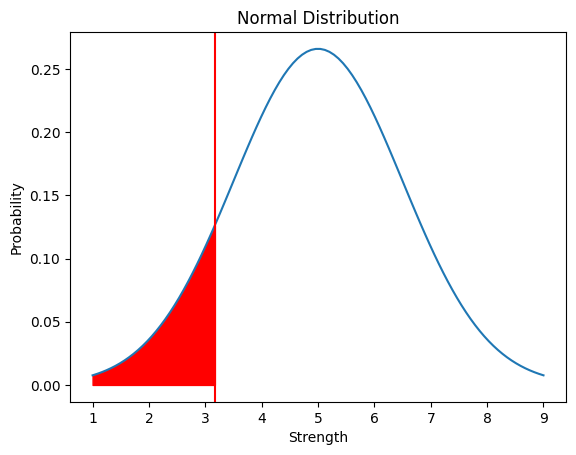

In [34]:
plt.plot(density["x"], density["pdf"])
plt.axvline(x=3.17, c="r")
x1 = np.linspace(density["x"].min(), 3.17, 50)
plt.fill_between(x1, norm.pdf(x1, 5, 1.5), color="r")
plt.xlabel("Strength")
plt.ylabel("Probability")
plt.title("Normal Distribution")
plt.show()

####2.2 What proportion of the gunny bags have a breaking strength at least 3.6 kg per sq cm.?


In [27]:
prob1 = 1- norm.cdf(3.6, 5, 1.5)
print(
    "The probability that gunny bag has a breaking strength of atleast 3.6 kg sq cm is",
    round(prob1, 4)
)

The probability that gunny bag has a breaking strength of atleast 3.6 kg sq cm is 0.8247


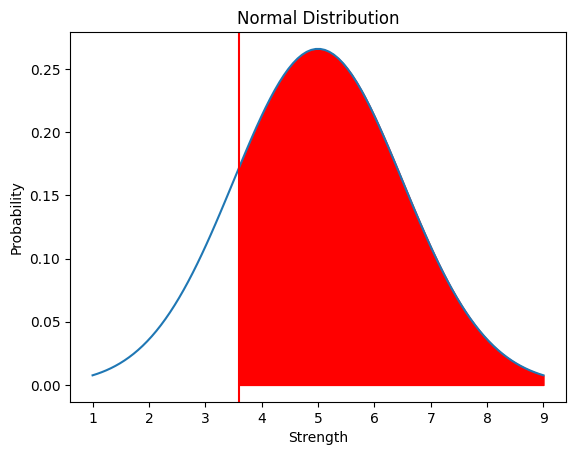

In [38]:
plt.plot(density["x"], density["pdf"])
plt.axvline(x=3.6, c="r")
x1 = np.linspace(density["x"].max(), 3.6, 50)
plt.fill_between(x1, norm.pdf(x1, 5, 1.5), color="r")
plt.xlabel("Strength")
plt.ylabel("Probability")
plt.title("Normal Distribution")
plt.show()

####2.3 What proportion of the gunny bags have a breaking strength between 5 and 5.5 kg per sq cm.?


In [28]:
prob2 = norm.cdf(5, 5, 1.5)
prob3 = norm.cdf(5.5, 5, 1.5)
print(
    "The probability that gunny bag has a breaking strength between 5 and 5.5 kg sq cm is",
    round(prob3-prob2, 4)
)

The probability that gunny bag has a breaking strength between 5 and 5.5 kg sq cm is 0.1306


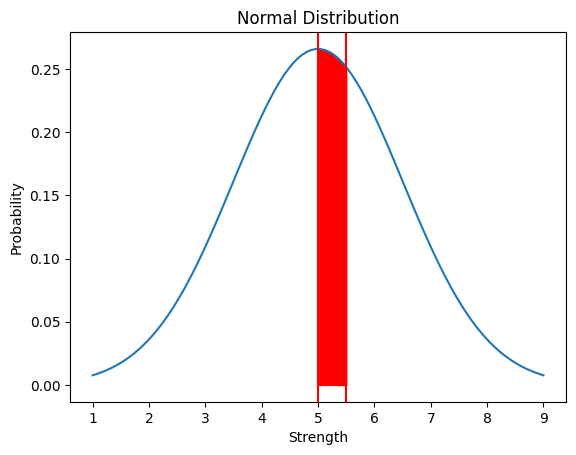

In [39]:
plt.plot(density["x"], density["pdf"])
plt.axvline(x=5, c="r")
plt.axvline(x=5.5, c="r")
x1 = np.linspace(5, 5.5, 50)
plt.fill_between(x1, norm.pdf(x1, 5, 1.5), color="r")
plt.xlabel("Strength")
plt.ylabel("Probability")
plt.title("Normal Distribution")
plt.show()

####2.4 What proportion of the gunny bags have a breaking strength NOT between 3 and 7.5 kg per sq cm.?


In [29]:
prob4 = norm.cdf(3,5,1.5)
prob5 = 1 - norm.cdf(7.5,5,1.5)
print(
    "The probability that gunny bag has a breaking strength not between 3 and 7.5 kg sq cm is",
    round(prob4 + prob5, 4)
)

The probability that gunny bag has a breaking strength not between 3 and 7.5 kg sq cm is 0.139


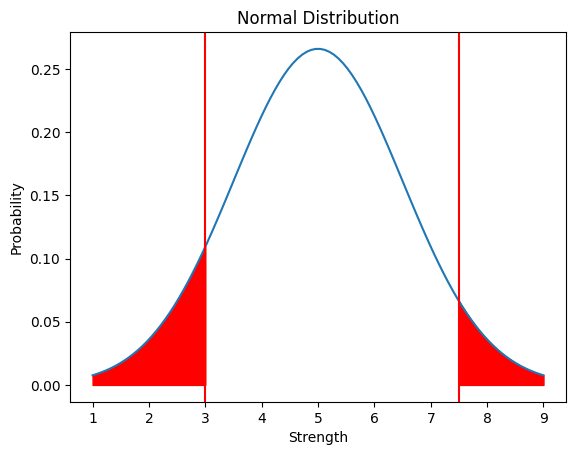

In [41]:
plt.plot(density["x"], density["pdf"])
plt.axvline(x=3, c="r")
x1 = np.linspace(density["x"].min(), 3, 50)
plt.fill_between(x1, norm.pdf(x1, 5, 1.5), color="r")
plt.axvline(x=7.5, c="r")
x1 = np.linspace(density["x"].max(), 7.5, 50)
plt.fill_between(x1, norm.pdf(x1, 5, 1.5), color="r")
plt.xlabel("Strength")
plt.ylabel("Probability")
plt.title("Normal Distribution")
plt.show()

## Problem 3

Zingaro stone printing is a company that specializes in printing images or patterns on polished or unpolished stones. However, for the optimum level of printing of the image, the stone surface has to have a Brinell's hardness index of at least 150. Recently, Zingaro has received a batch of polished and unpolished stones from its clients. Use the data provided to answer the following (assuming a 5% significance level);

Understanding Data

In [43]:
df.head()

,Unpolished,Treated and Polished
0,164.481713,133.209393
1,154.307045,138.482771
2,129.861048,159.665201
3,159.096184,145.663528
4,135.256748,136.789227


In [44]:
df.describe(include='all')

,Unpolished,Treated and Polished
count,75.000000,75.000000
mean,134.110527,147.788117
std,33.041804,15.587355
min,48.406838,107.524167
25%,115.329753,138.268300
50%,135.597121,145.721322
75%,158.215098,157.373318
max,200.161313,192.272856


####3.1 Zingaro has reason to believe that the unpolished stones may not be suitable for printing. Do you think Zingaro is justified in thinking so?


**Let's write the null and alternative hypothesis**

Let $\mu$ be the mean Hardness be 150

We will test the null hypothesis

> H0: mu = 150

Hardness index is equal to 150

against the alternate hypothesis

> HA: mu < 150

Hardness index is not equal to 150


Let's test whether the T-test assumptions are satisfied or not

* Continuous data

*   Normally distributed population
*   Observations are from a simple random sample - Yes, we are informed that the collected sample a simple random sample.
*   Population standard deviation is known - No

We can use T-test for this problem.

In [53]:
df.columns = df.columns.str.strip()

In [55]:
from scipy.stats import ttest_1samp

test_stat, p_value = ttest_1samp(df['Unpolished'], popmean = 150, alternative = 'less')
print('The p-value is ', p_value)

The p-value is  4.171286997419652e-05


**Insight**
As the p-value is much less than the level of significance, we have enough evidence to reject the null hypothesis. Therefore, unpolished stone do not
have a hardness index of atleast 150.

####3.2 Is the mean hardness of the polished and unpolished stones the same?


Let's write the null and alternative hypothesis


Let $\mu_1, \mu_2$ be the mean hardness of **Unpolished** and **Treated and Polished** groups respectively.

We will test the null hypothesis

>$H_0:\mu_1=\mu_2$

against the alternate hypothesis

>$H_a:\mu_1>\mu_2$

In [59]:
print('The mean hardness for Unpolished group is ' + str(df['Unpolished'].mean()))
print('The mean hardness for Treated and Polished group is ' + str(df['Treated and Polished'].mean()))
print('The standard deviation of hardness for Unpolished group is ' + str(round(df['Unpolished'].std(),2)))
print('The standard deviation of hardness for Treated and Polished group is ' + str(round(df['Treated and Polished'].std(), 2)))

The mean hardness for Unpolished group is 134.11052653373332
The mean hardness for Treated and Polished group is 147.78811718133335
The standard deviation of hardness for Unpolished group is 33.04
The standard deviation of hardness for Treated and Polished group is 15.59


Let's test whether the T-test assumptions are satisfied or not

* Continuous data
* Normally distributed populations - Yes, we are informed that the populations are assumed to be normal.
* Independent populations - As we are taking random samples for two different groups, the two samples are from two independent populations.
* Unequal population standard deviations - As the sample standard deviations are different, the population standard deviations may be assumed to be different.
* Random sampling from the population - Yes, we are informed that the collected sample a simple random sample.

We can use two sample T-test for this problem.



In [66]:
from scipy.stats import ttest_ind

test_stat, p_value = ttest_ind(df['Unpolished'], df['Treated and Polished'].dropna(), equal_var = False, alternative = 'greater')
print('The p-value is ', p_value)

The p-value is  0.9992058103522078


**Insight:** As the p-value is more than the level of significance, we can not reject the null hypothesis. Hence, we do have enough evidence to conclude that the mean of hardness of unpolished stone and that of polished and treated are equal

# Problem 4

In [67]:
df1.head()

,Dentist,Method,Alloy,Temp,Response
0,1,1,1,1500,813
1,1,1,1,1600,792
2,1,1,1,1700,792
3,1,1,2,1500,907
4,1,1,2,1600,792


In [68]:
df1.describe(include='all')

,Dentist,Method,Alloy,Temp,Response
count,90.000000,90.000000,90.000000,90.000000,90.000000
mean,3.000000,2.000000,1.500000,1600.000000,741.777778
std,1.422136,0.821071,0.502801,82.107083,145.767845
min,1.000000,1.000000,1.000000,1500.000000,289.000000
25%,2.000000,1.000000,1.000000,1500.000000,698.000000
50%,3.000000,2.000000,1.500000,1600.000000,767.000000
75%,4.000000,3.000000,2.000000,1700.000000,824.000000
max,5.000000,3.000000,2.000000,1700.000000,1115.000000


In [82]:
alloy1 = df1.loc[df1['Alloy'] == 1]
alloy2 = df1.loc[df1['Alloy'] == 2]

##4.1 How does the hardness of implants vary depending on dentists?


### Let's write the null and alternative hypothesis

Let mu1 , mu2 , mu3  , mu4 and mu5 be the means of response for dentist 1, 2, 3, 4 and 5 respectively.

We will test the null hypothesis

>H0: mu1 = mu2 = mu3 = mu4 = mu5

against the alternative hypothesis

>H1:  At least one hardness level is different from the rest.


### **Alloy 1**

In [97]:
alloy1['Dentist'].value_counts()

,count
Dentist,
1,9
2,9
3,9
4,9
5,9


Dentist
1    749.888889
2    761.222222
3    717.555556
4    681.111111
5    627.666667
Name: Response, dtype: float64


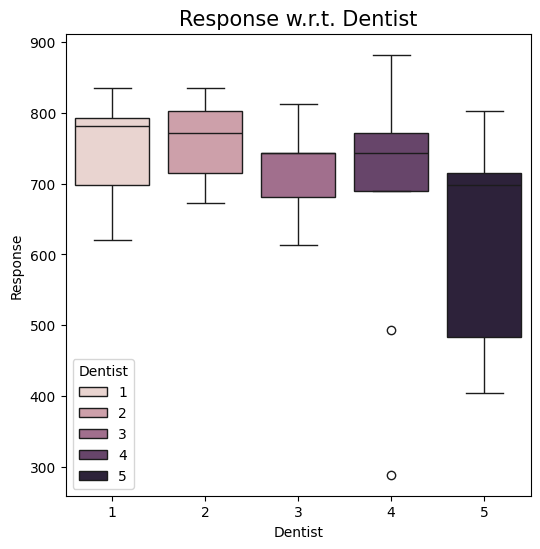

In [86]:
# mean of response for different dentist
print(alloy1.groupby("Dentist")["Response"].mean())

# draw the boxplot for visualization
fig, ax = plt.subplots(figsize = (6,6))
a = sns.boxplot(x= "Dentist", y = 'Response' , data = alloy1, hue = 'dentist')
a.set_title("Response w.r.t. Dentist", fontsize=15)
plt.show()

Since the question states that we need to proceed with the test even if the assumptions fail, we are not performing Shapiro's Wilk Test and Levene's Test


In [99]:
#import the required function
from scipy.stats import f_oneway

# perform one-way anova test
test_stat, p_value = f_oneway(alloy1.loc[alloy1['Dentist'] == '1', 'Response'],
                              alloy1.loc[alloy1['Dentist'] == '2', 'Response'],
                              alloy1.loc[alloy1['Dentist'] == '3', 'Response'],
                              alloy1.loc[alloy1['Dentist'] == '4', 'Response'],
                              alloy1.loc[alloy1['Dentist'] == '5', 'Response'])
print('The p-value is ' + str(p_value))

The p-value is nan


The code gives nan error may be because the sample size is too small or failure of Shapiro Wilk's Test or Leven's Test, however we may continue with our project by using Turkey Test


In [95]:
#import the required function
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# perform multiple pairwise comparison (Tukey HSD)
m_comp = pairwise_tukeyhsd(endog = alloy1['Response'], groups = alloy1['Dentist'], alpha = 0.05)
print(m_comp)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower    upper   reject
--------------------------------------------------------
     1      2   11.3333 0.9996 -145.0423  167.709  False
     1      3  -32.3333 0.9757  -188.709 124.0423  False
     1      4  -68.7778 0.7189 -225.1535  87.5979  False
     1      5 -122.2222 0.1889 -278.5979  34.1535  False
     2      3  -43.6667 0.9298 -200.0423  112.709  False
     2      4  -80.1111 0.5916 -236.4868  76.2646  False
     2      5 -133.5556 0.1258 -289.9312  22.8201  False
     3      4  -36.4444 0.9626 -192.8201 119.9312  False
     3      5  -89.8889 0.4805 -246.2646  66.4868  False
     4      5  -53.4444 0.8643 -209.8201 102.9312  False
--------------------------------------------------------


**Insight**

As the p-values (refer to the p-adj column) for comparing the mean response for the dentist pair is more than the significance level, the null hypothesis of equality of all population means can not be rejected.

Thus, we can say that the mean response for all dentist are similar.

### **Alloy 2**

In [100]:
alloy2['Dentist'].value_counts()

,count
Dentist,
1,9
2,9
3,9
4,9
5,9


Dentist
1    816.222222
2    812.111111
3    779.666667
4    746.222222
5    726.111111
Name: Response, dtype: float64


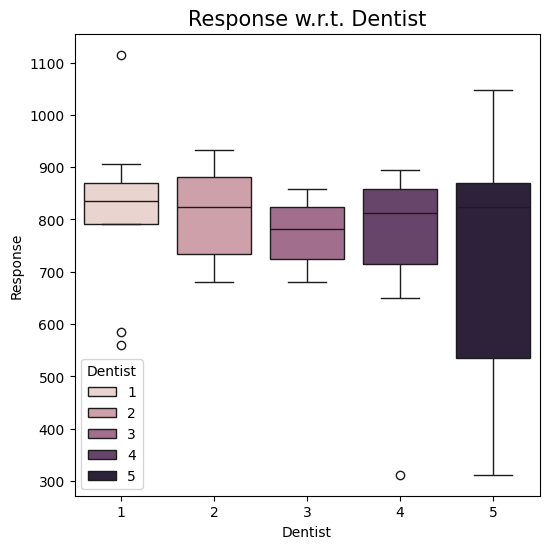

In [102]:
# mean of response for different dentist
print(alloy2.groupby("Dentist")["Response"].mean())

# draw the boxplot for visualization
fig, ax = plt.subplots(figsize = (6,6))
a = sns.boxplot(x= "Dentist", y = 'Response' , data = alloy2, hue = 'Dentist')
a.set_title("Response w.r.t. Dentist", fontsize=15)
plt.show()

Since the question states that we need to proceed with the test even if the assumptions fail, we are not performing Shapiro's Wilk Test and Levene's Test

In [105]:
#import the required function
from scipy.stats import f_oneway

# perform one-way anova test
test_stat, p_value = f_oneway(alloy2.loc[alloy2['Dentist'] == '1', 'Response'],
                              alloy2.loc[alloy2['Dentist'] == '2', 'Response'],
                              alloy2.loc[alloy2['Dentist'] == '3', 'Response'],
                              alloy2.loc[alloy2['Dentist'] == '4', 'Response'],
                              alloy2.loc[alloy2['Dentist'] == '5', 'Response'])
print('The p-value is ' + str(p_value))

The p-value is nan


/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:4102: DegenerateDataWarning: at least one input has length 0
  if _f_oneway_is_too_small(samples):


The code gives nan error may be because the sample size is too small or failure of Shapiro Wilk's Test or Leven's Test, however we may continue with our project by using Turkey Test

In [106]:
#import the required function
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# perform multiple pairwise comparison (Tukey HSD)
m_comp = pairwise_tukeyhsd(endog = alloy2['Response'], groups = alloy2['Dentist'], alpha = 0.05)
print(m_comp)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj    lower    upper   reject
-------------------------------------------------------
     1      2  -4.1111    1.0 -225.5687 217.3465  False
     1      3 -36.5556 0.9895 -258.0131  184.902  False
     1      4    -70.0 0.8941 -291.4576 151.4576  False
     1      5 -90.1111 0.7724 -311.5687 131.3465  False
     2      3 -32.4444 0.9933  -253.902 189.0131  False
     2      4 -65.8889 0.9132 -287.3465 155.5687  False
     2      5    -86.0 0.8008 -307.4576 135.4576  False
     3      4 -33.4444 0.9925  -254.902 188.0131  False
     3      5 -53.5556 0.9574 -275.0131  167.902  False
     4      5 -20.1111  0.999 -241.5687 201.3465  False
-------------------------------------------------------


**Insight**

As the p-values (refer to the p-adj column) for comparing the mean response for the dentist pair is more than the significance level, the null hypothesis of equality of all population means can not be rejected.

Thus, we can say that the mean response for all dentist are similar.

##4.2 How does the hardness of implants vary depending on methods?


### Let's write the null and alternative hypothesis

Let mu1, mu2 and mu3 be the means of response for method 1, 2 and 3 respectively.

We will test the null hypothesis

>H0: mu1 = mu2 = mu3

against the alternative hypothesis

>H1: At least one hardness level is different from the rest.


###**Alloy 1**

In [107]:
alloy1['Method'].value_counts()

,count
Method,
1,15
2,15
3,15


Method
1    751.133333
2    745.000000
3    626.333333
Name: Response, dtype: float64


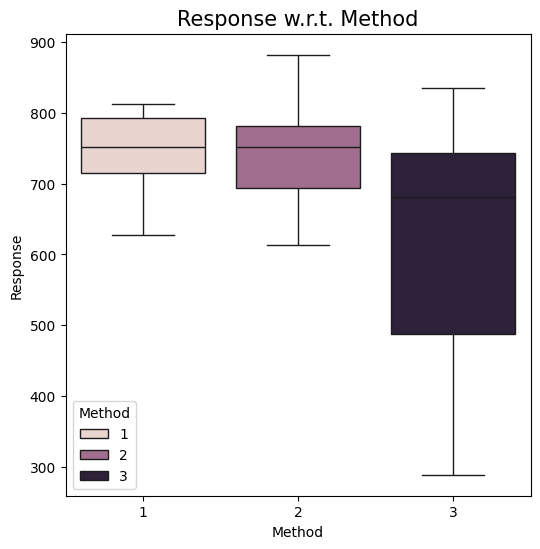

In [108]:
# mean of response for different dentist
print(alloy1.groupby("Method")["Response"].mean())

# draw the boxplot for visualization
fig, ax = plt.subplots(figsize = (6,6))
a = sns.boxplot(x= "Method", y = 'Response' , data = alloy1, hue = 'Method')
a.set_title("Response w.r.t. Method", fontsize=15)
plt.show()

Since the question states that we need to proceed with the test even if the assumptions fail, we are not performing Shapiro's Wilk Test and Levene's Test


In [109]:
#import the required function
from scipy.stats import f_oneway

# perform one-way anova test
test_stat, p_value = f_oneway(alloy1.loc[alloy1['Method'] == '1', 'Response'],
                              alloy1.loc[alloy1['Method'] == '2', 'Response'],
                              alloy1.loc[alloy1['Method'] == '3', 'Response'])
print('The p-value is ' + str(p_value))

The p-value is nan


/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:4102: DegenerateDataWarning: at least one input has length 0
  if _f_oneway_is_too_small(samples):


The code gives nan error may be because the sample size is too small or failure of Shapiro Wilk's Test or Leven's Test, however we may continue with our project by using Turkey Test


In [111]:
#import the required function
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# perform multiple pairwise comparison (Tukey HSD)
m_comp = pairwise_tukeyhsd(endog = alloy1['Response'], groups = alloy1['Method'], alpha = 0.05)
print(m_comp)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower    upper   reject
--------------------------------------------------------
     1      2   -6.1333  0.987  -102.714  90.4473  False
     1      3    -124.8 0.0085 -221.3807 -28.2193   True
     2      3 -118.6667 0.0128 -215.2473  -22.086   True
--------------------------------------------------------


**Insight**

Based on p value, mean response of method 1 & 2 is similar but for others it is not. Therefore mean of all responses are not equal.


###**Alloy 2**

In [114]:
alloy2['Method'].value_counts()

,count
Method,
1,15
2,15
3,15


Method
1    836.666667
2    863.666667
3    627.866667
Name: Response, dtype: float64


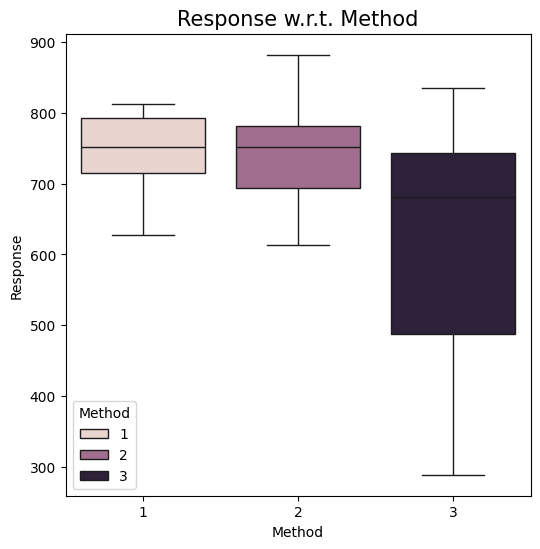

In [113]:
# mean of response for different dentist
print(alloy2.groupby("Method")["Response"].mean())

# draw the boxplot for visualization
fig, ax = plt.subplots(figsize = (6,6))
a = sns.boxplot(x= "Method", y = 'Response' , data = alloy1, hue = 'Method')
a.set_title("Response w.r.t. Method", fontsize=15)
plt.show()

Since the question states that we need to proceed with the test even if the assumptions fail, we are not performing Shapiro's Wilk Test and Levene's Test

In [116]:
#import the required function
from scipy.stats import f_oneway

# perform one-way anova test
test_stat, p_value = f_oneway(alloy2.loc[alloy2['Method'] == '1', 'Response'],
                              alloy2.loc[alloy2['Method'] == '2', 'Response'],
                              alloy2.loc[alloy2['Method'] == '3', 'Response'])
print('The p-value is ' + str(p_value))

The p-value is nan


/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:4102: DegenerateDataWarning: at least one input has length 0
  if _f_oneway_is_too_small(samples):


In [130]:
#import the required function
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# perform multiple pairwise comparison (Tukey HSD)
m_comp = pairwise_tukeyhsd(endog = alloy2['Response'], groups = alloy2['Method'], alpha = 0.05)
print(m_comp)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2 meandiff p-adj    lower     upper   reject
--------------------------------------------------------
     1      2     27.0 0.8212  -82.4546  136.4546  False
     1      3   -208.8 0.0001 -318.2546  -99.3454   True
     2      3   -235.8    0.0 -345.2546 -126.3454   True
--------------------------------------------------------


The code gives nan error may be because the sample size is too small or failure of Shapiro Wilk's Test or Leven's Test, however we may continue with our project by using Turkey Test

**Insight**

Based on p value, mean response of method 1 & 2 is similar but for others it is not. Therefore mean of all responses are not equal.


##4.3 What is the interaction effect between the dentist and method on the hardness of dental implants for each type of alloy?


Alloy 1

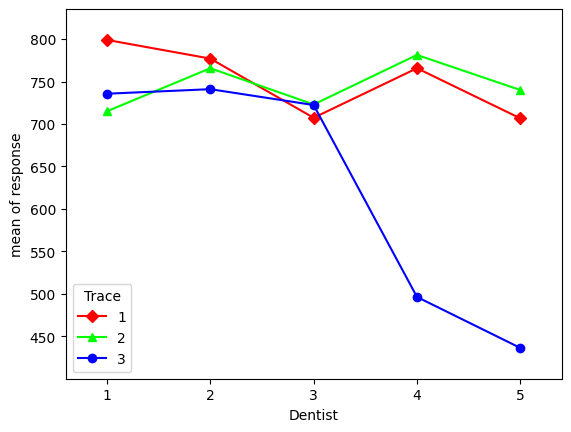

In [133]:
from statsmodels.graphics.factorplots import interaction_plot
interaction_plot(np.array(alloy1['Dentist']),np.array(alloy1['Method']),np.array(alloy1['Response']),markers=['D','^','o'])
plt.xlabel("Dentist");

We can see that there is some interaction between Dentist and Method


Alloy 2

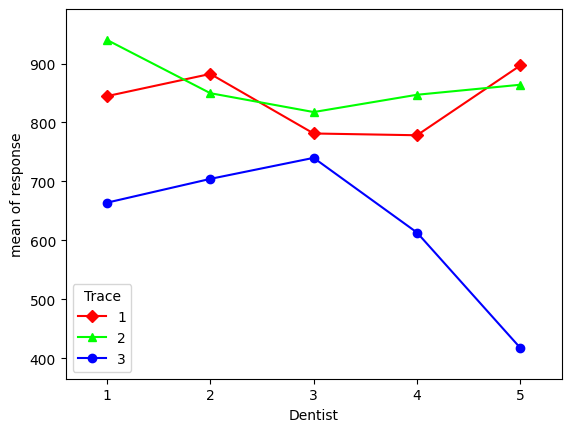

In [132]:
from statsmodels.graphics.factorplots import interaction_plot
interaction_plot(np.array(alloy2['Dentist']),np.array(alloy2['Method']),np.array(alloy2['Response']),markers=['D','^','o'])
plt.xlabel("Dentist");

We can see that there is some interaction between Dentist and Method


##4.4 How does the hardness of implants vary depending on dentists and methods together?


In [126]:
from statsmodels.formula.api import ols      # For n-way ANOVA
from statsmodels.stats.anova import _get_covariance,anova_lm # For n-way ANOVA

#### **Step 1: Define null and alternative hypotheses for Two-Way ANONA**

The null and alternative hypotheses can be formulated as:

> $H_0$ : The effect of `dentist` on `hardness of implant` does not depend on the effect of the `method` variable (a.k.a. no interaction effect)

> $H_a$ : There is an interaction effect between `dentist` and `method` on `hardness of implant`.

#### **Step 2: Select Appropriate test**

This is a problem, concerning the effect of two independent variables on a dependent variable. **Two-way ANOVA test** is an appropriate test here.

Following are the assumptions of the Two-way ANOVA test:

* The populations from which the samples are obtained must be normally distributed.
* Sampling is done correctly. Observations for within and between groups must be independent.
* The variances among populations must be equal (homoscedastic).
* The dependent data must be measured at an interval scale.




#### **Step 3: Calculation of p-value (for Alloy 1)**

As given in the problem statement, we select $\alpha = 0.05$

In [127]:
formula = 'Response ~ C(Dentist) + C(Method) + C(Dentist):C(Method)'
model = ols(formula, alloy1).fit()
alloy1_table = anova_lm(model)
(alloy1_table)

,df,sum_sq,mean_sq,F,PR(>F)
C(Dentist),4.0,106683.688889,26670.922222,3.899638,0.011484
C(Method),2.0,148472.177778,74236.088889,10.854287,0.000284
C(Dentist):C(Method),8.0,185941.377778,23242.672222,3.398383,0.006793
Residual,30.0,205180.000000,6839.333333,NaN,NaN


As the p-value is less than 0.05, we have sufficient evidence to reject the null hypothesis, Hence, The effect of `Dentist` on `Hardness of Implant` does depend on the effect of the `Method` variable.

#### **Step 3A: Calculation of p-value (for Alloy 2)**

As given in the problem statement, we select $\alpha = 0.05$

In [129]:
model = ols(formula, alloy2).fit()
alloy2_table = anova_lm(model)
(alloy2_table)

,df,sum_sq,mean_sq,F,PR(>F)
C(Dentist),4.0,56797.911111,14199.477778,1.106152,0.371833
C(Method),2.0,499640.400000,249820.200000,19.461218,0.000004
C(Dentist):C(Method),8.0,197459.822222,24682.477778,1.922787,0.093234
Residual,30.0,385104.666667,12836.822222,NaN,NaN


As the p-value is more than 0.05, we do not have sufficient evidence to reject the null hypothesis, Hence, The effect of `Dentist` on `Hardness of Implant` does not depend on the effect of the `Method` variable.